## B-Random Forest (Model + LIME Explainability)

## 1. Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import arff
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import lime
import lime.lime_tabular

RANDOM_STATE = 42
plt.rcParams.update({"figure.dpi": 120, "font.family": "sans-serif", "axes.spines.top": False, "axes.spines.right": False})
print("All libraries loaded.")

All libraries loaded.


## 2. Load and Inspect the Dataset

In [3]:
raw_data, meta = arff.loadarff("dataset_31_credit-g.arff")
df = pd.DataFrame(raw_data)
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.decode("utf-8")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Missing values: {df.isnull().sum().sum()}")
df.head()

Shape: 1000 rows x 21 columns
Missing values: 0


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6.0,critical/other existing credit,radio/tv,1169.0,no known savings,>=7,4.0,male single,none,...,real estate,67.0,none,own,2.0,skilled,1.0,yes,yes,good
1,0<=X<200,48.0,existing paid,radio/tv,5951.0,<100,1<=X<4,2.0,female div/dep/mar,none,...,real estate,22.0,none,own,1.0,skilled,1.0,none,yes,bad
2,no checking,12.0,critical/other existing credit,education,2096.0,<100,4<=X<7,2.0,male single,none,...,real estate,49.0,none,own,1.0,unskilled resident,2.0,none,yes,good
3,<0,42.0,existing paid,furniture/equipment,7882.0,<100,4<=X<7,2.0,male single,guarantor,...,life insurance,45.0,none,for free,1.0,skilled,2.0,none,yes,good
4,<0,24.0,delayed previously,new car,4870.0,<100,1<=X<4,3.0,male single,none,...,no known property,53.0,none,for free,2.0,skilled,2.0,none,yes,bad


In [4]:
print(df.dtypes)

checking_status            object
duration                  float64
credit_history             object
purpose                    object
credit_amount             float64
savings_status             object
employment                 object
installment_commitment    float64
personal_status            object
other_parties              object
residence_since           float64
property_magnitude         object
age                       float64
other_payment_plans        object
housing                    object
existing_credits          float64
job                        object
num_dependents            float64
own_telephone              object
foreign_worker             object
class                      object
dtype: object


Class distribution:
class
good    700
bad     300
Name: count, dtype: int64


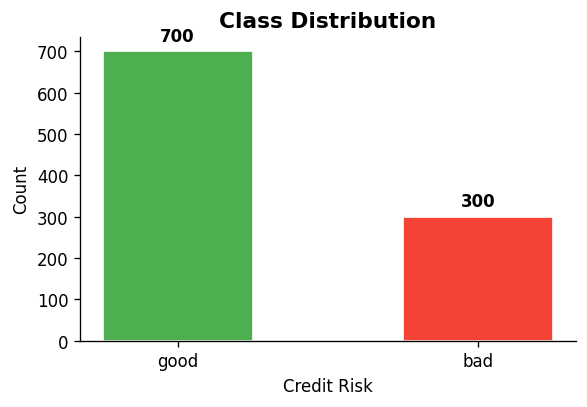

In [5]:
print("Class distribution:")
print(df["class"].value_counts())

fig, ax = plt.subplots(figsize=(5, 3.5))
counts = df["class"].value_counts()
bars = ax.bar(counts.index, counts.values, color=["#4CAF50", "#F44336"], edgecolor="white", width=0.5)
ax.bar_label(bars, fmt="%d", padding=4, fontweight="bold")
ax.set_title("Class Distribution", fontsize=13, fontweight="bold")
ax.set_xlabel("Credit Risk")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

## 3. Preprocessing - Encode Categorical Features

In [6]:
df_encoded = df.copy()
label_encoders = {}
categorical_cols = df_encoded.select_dtypes(include="object").columns.tolist()

for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

print(f"Encoded {len(categorical_cols)} categorical columns:")
print(categorical_cols)
df_encoded.head()

Encoded 14 categorical columns:
['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker', 'class']


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,1,6.0,1,6,1169.0,4,3,4.0,3,2,...,3,67.0,1,1,2.0,1,1.0,1,1,1
1,0,48.0,3,6,5951.0,2,0,2.0,0,2,...,3,22.0,1,1,1.0,1,1.0,0,1,0
2,3,12.0,1,2,2096.0,2,1,2.0,3,2,...,3,49.0,1,1,1.0,3,2.0,0,1,1
3,1,42.0,3,3,7882.0,2,1,2.0,3,1,...,1,45.0,1,0,1.0,1,2.0,0,1,1
4,1,24.0,2,4,4870.0,2,0,3.0,3,2,...,2,53.0,1,0,2.0,1,2.0,0,1,0


## 4. Train / Test Split

In [7]:
X = df_encoded.drop(columns=["class"])
y = df_encoded["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")
print(f"Features         : {X_train.shape[1]}")

Training samples : 700
Testing  samples : 300
Features         : 20


## 5. Train the Random Forest

In [8]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf.fit(X_train, y_train)
print("Random Forest trained.")
print(f"  Trees         : {rf.n_estimators}")
print(f"  Features used : {rf.n_features_in_}")

Random Forest trained.
  Trees         : 200
  Features used : 20


## 6. Evaluate Performance

In [9]:
y_pred = rf.predict(X_test)

le_class = label_encoders["class"]
target_names = le_class.classes_

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

Accuracy : 0.7300  (73.00%)

Classification Report:
              precision    recall  f1-score   support

         bad       0.57      0.41      0.48        90
        good       0.77      0.87      0.82       210

    accuracy                           0.73       300
   macro avg       0.67      0.64      0.65       300
weighted avg       0.71      0.73      0.72       300



## 7. Confusion Matrix

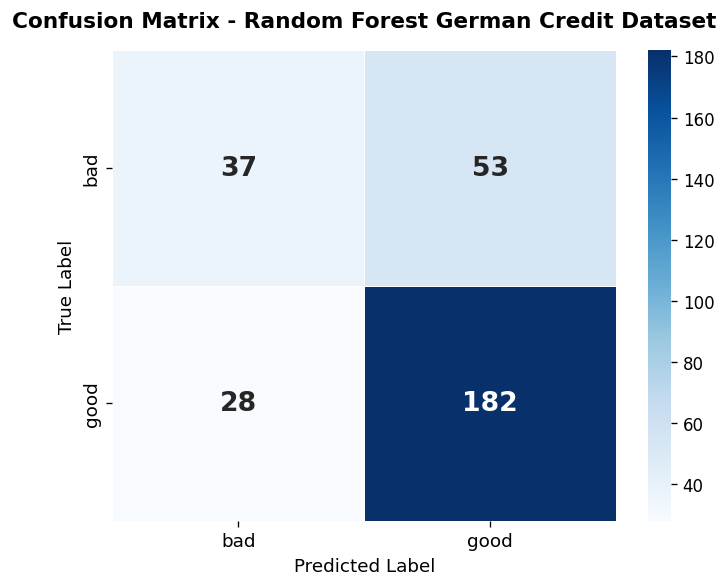

True  Negatives (bad  -> bad)  : 37
False Positives (bad  -> good) : 53
False Negatives (good -> bad)  : 28
True  Positives (good -> good) : 182


In [10]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    linewidths=0.5, linecolor="white",
    xticklabels=target_names, yticklabels=target_names,
    ax=ax, annot_kws={"size": 16, "weight": "bold"}
)
ax.set_title("Confusion Matrix - Random Forest German Credit Dataset", fontsize=13, fontweight="bold", pad=14)
ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label", fontsize=11)
ax.tick_params(axis="both", labelsize=11)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True  Negatives (bad  -> bad)  : {tn}")
print(f"False Positives (bad  -> good) : {fp}")
print(f"False Negatives (good -> bad)  : {fn}")
print(f"True  Positives (good -> good) : {tp}")

## 8. Explainability (Random Forest): LIME

LIME (Local Interpretable Model-agnostic Explanations) explains individual predictions by fitting a simple linear model in the neighbourhood of each instance.  
It is **model-agnostic** — it only calls `predict_proba` as a black box — which makes it directly comparable to Anchors and complementary to SHAP.

### Case Picker

In [11]:
class_names_list = list(label_encoders["class"].classes_)
bad_label  = class_names_list.index("bad")
good_label = class_names_list.index("good")

pred_labels = rf.predict(X_test)

bad_idxs  = np.where(pred_labels == bad_label)[0]
good_idxs = np.where(pred_labels == good_label)[0]
mis_idxs  = np.where(pred_labels != y_test.values)[0]

bad_i  = int(bad_idxs[0])  if len(bad_idxs)  else None
good_i = int(good_idxs[0]) if len(good_idxs) else None

# pick a misclassified index that differs from bad_i and good_i
mis_i = None
for idx in mis_idxs:
    idx = int(idx)
    if idx != bad_i and idx != good_i:
        mis_i = idx
        break

print("Selected indices in RF test set:")
print("  BAD predicted :", bad_i)
print("  GOOD predicted:", good_i)
print("  Misclassified :", mis_i)

Selected indices in RF test set:
  BAD predicted : 4
  GOOD predicted: 0
  Misclassified : 8


### Build the LIME Explainer

In [12]:
feature_names = list(X_train.columns)
X_train_np = X_train.to_numpy()
X_test_np  = X_test.to_numpy()

# Identify encoded categorical column indices for LIME
categorical_cols_original = [
    c for c in df.select_dtypes(include="object").columns.tolist()
    if c != "class"
]
categorical_feature_indices = [
    feature_names.index(c) for c in categorical_cols_original if c in feature_names
]

# Predict wrapper that accepts a plain numpy array (LIME requirement)
def predict_fn_proba(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x)
    if x.ndim == 1:
        x = x.reshape(1, -1)
    x_df = pd.DataFrame(x, columns=feature_names)
    return rf.predict_proba(x_df)

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_np,
    feature_names=feature_names,
    class_names=class_names_list,
    categorical_features=categorical_feature_indices,
    mode="classification",
    random_state=RANDOM_STATE
)

print("LIME explainer created.")
print(f"  Features          : {len(feature_names)}")
print(f"  Categorical cols  : {len(categorical_feature_indices)}")
print(f"  Classes           : {class_names_list}")

LIME explainer created.
  Features          : 20
  Categorical cols  : 13
  Classes           : ['bad', 'good']


### Global Feature Importance via LIME (mean |weight| over test set)

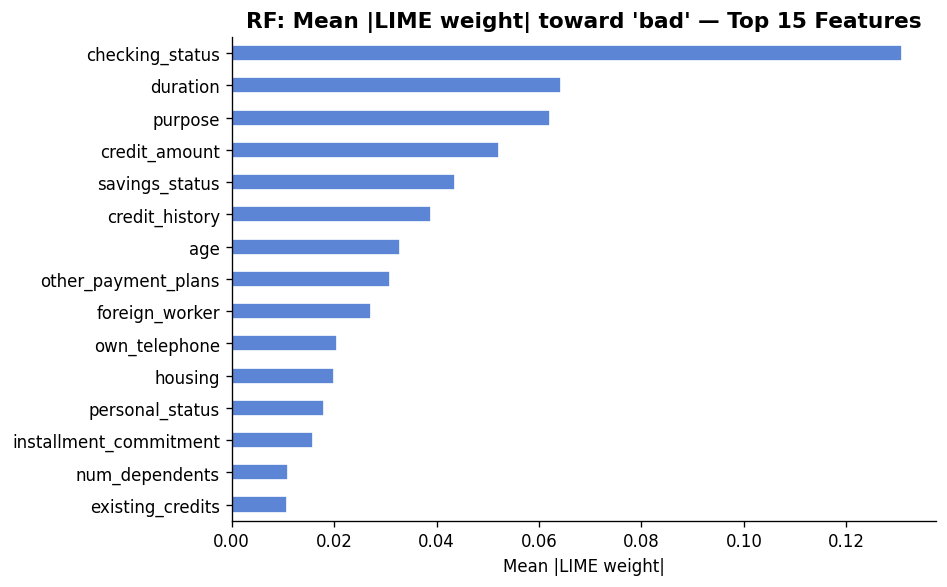

checking_status           0.130951
duration                  0.064352
purpose                   0.062230
credit_amount             0.052186
savings_status            0.043523
credit_history            0.038925
age                       0.032796
other_payment_plans       0.030972
foreign_worker            0.027208
own_telephone             0.020555
housing                   0.020034
personal_status           0.017937
installment_commitment    0.015900
num_dependents            0.011079
existing_credits          0.010813
dtype: float64

In [ ]:
# Aggregate LIME weights across the whole test set to get a global importance picture.
# For each instance we collect the signed weight for each feature (toward 'bad').
# We then take the mean absolute value per feature.

weight_matrix = np.zeros((len(X_test_np), len(feature_names)))

for i in range(len(X_test_np)):
    exp = lime_explainer.explain_instance(
        X_test_np[i],
        predict_fn_proba,
        num_features=len(feature_names),
        labels=(bad_label,)
    )
    
    for feat_idx, weight in exp.as_map()[bad_label]:
            weight_matrix[i, feat_idx] = weight

mean_abs_weights = np.abs(weight_matrix).mean(axis=0)
importance_series = pd.Series(mean_abs_weights, index=feature_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
importance_series.head(15).sort_values().plot(kind="barh", ax=ax, color="#5C85D6", edgecolor="white")
ax.set_title("RF: Mean |LIME weight| toward 'bad' — Top 15 Features", fontsize=13, fontweight="bold")
ax.set_xlabel("Mean |LIME weight|")
plt.tight_layout()
plt.show()

importance_series.head(15)

### Local LIME Explanations — BAD, GOOD, Misclassified

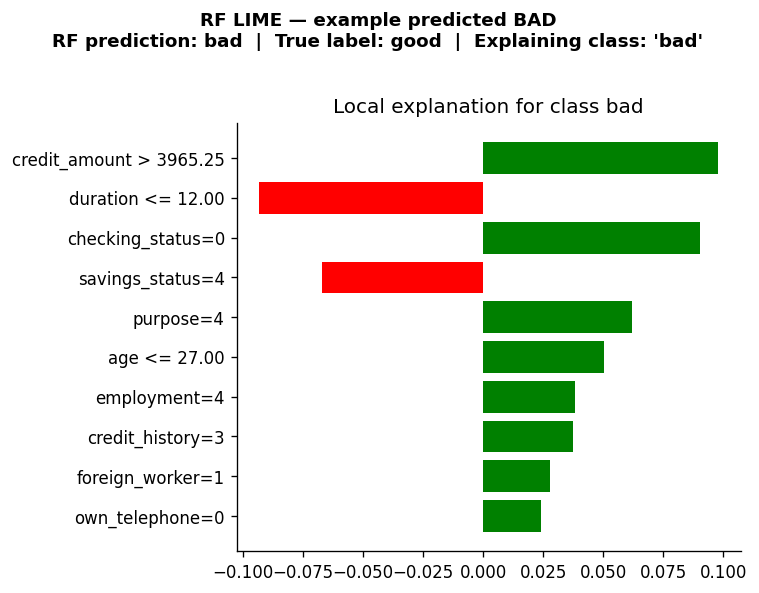


[RF LIME — example predicted BAD]  top-10 feature contributions toward 'bad':
  +  0.0977   credit_amount > 3965.25
  -  0.0932   duration <= 12.00
  +  0.0903   checking_status=0
  -  0.0670   savings_status=4
  +  0.0618   purpose=4
  +  0.0502   age <= 27.00
  +  0.0380   employment=4
  +  0.0374   credit_history=3
  +  0.0279   foreign_worker=1
  +  0.0238   own_telephone=0



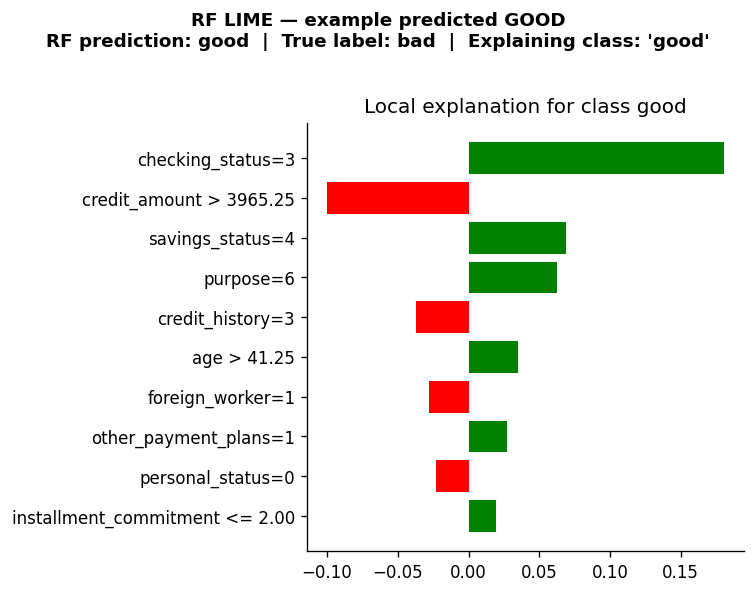


[RF LIME — example predicted GOOD]  top-10 feature contributions toward 'good':
  +  0.1807   checking_status=3
  -  0.1002   credit_amount > 3965.25
  +  0.0687   savings_status=4
  +  0.0622   purpose=6
  -  0.0372   credit_history=3
  +  0.0353   age > 41.25
  -  0.0281   foreign_worker=1
  +  0.0272   other_payment_plans=1
  -  0.0227   personal_status=0
  +  0.0197   installment_commitment <= 2.00



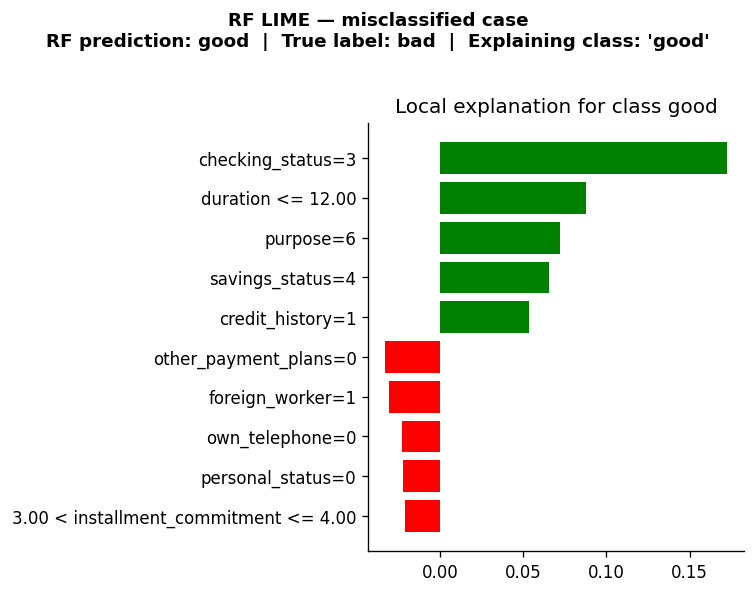


[RF LIME — misclassified case]  top-10 feature contributions toward 'good':
  +  0.1724   checking_status=3
  +  0.0879   duration <= 12.00
  +  0.0721   purpose=6
  +  0.0653   savings_status=4
  +  0.0532   credit_history=1
  -  0.0330   other_payment_plans=0
  -  0.0308   foreign_worker=1
  -  0.0231   own_telephone=0
  -  0.0222   personal_status=0
  -  0.0209   3.00 < installment_commitment <= 4.00



In [ ]:
def show_lime_local(idx: int, title: str, label: int = None):
    """Run LIME for one instance and show the bar-chart explanation."""
    if idx is None:
        print(f"[{title}] — no valid index found, skipping.")
        return

    exp = lime_explainer.explain_instance(
        X_test_np[idx],
        predict_fn_proba,
        num_features=10,
        labels=(bad_label, good_label)
    )

    focus_label = label if label is not None else int(rf.predict(X_test.iloc[[idx]])[0])

    fig = exp.as_pyplot_figure(label=focus_label)
    pred_name = class_names_list[int(rf.predict(X_test.iloc[[idx]])[0])]
    true_name = class_names_list[int(y_test.iloc[idx])]
    fig.suptitle(
        f"{title}\nRF prediction: {pred_name}  |  True label: {true_name}  |  Explaining class: '{class_names_list[focus_label]}'",
        fontsize=11, fontweight="bold", y=1.02
    )
    plt.tight_layout()
    plt.show()

    print(f"\n[{title}]  top-10 feature contributions toward '{class_names_list[focus_label]}':")
    for feat, weight in exp.as_list(label=focus_label):
        direction = "+" if weight > 0 else "-"
        print(f"  {direction}  {abs(weight):.4f}   {feat}")
    print()

# BAD-predicted instance — explain toward 'bad'
show_lime_local(bad_i,  "RF LIME — example predicted BAD",   label=bad_label)

# GOOD-predicted instance — explain toward 'good'
show_lime_local(good_i, "RF LIME — example predicted GOOD",  label=good_label)

# Misclassified instance — explain toward the predicted (incorrect) class
if mis_i is not None:
    mis_pred = int(rf.predict(X_test.iloc[[mis_i]])[0])
    show_lime_local(mis_i, "RF LIME — misclassified case", label=mis_pred)

---
## Decision Tree Model + LIME Explainability

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import ConfusionMatrixDisplay

# Re-encode using a single shared LabelEncoder 
le_dt = LabelEncoder()
X_dt = df.drop(columns=["class"]).copy()
for col in X_dt.select_dtypes(include="object").columns:
    X_dt[col] = le_dt.fit_transform(X_dt[col])

y_dt = le_dt.fit_transform(df["class"])
dt_class_names = le_dt.classes_

X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(
    X_dt, y_dt, test_size=0.3, random_state=RANDOM_STATE
)

clf = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)
clf.fit(X_train_dt, y_train_dt)

from sklearn.metrics import accuracy_score as _acc
print(f"DT Train accuracy : {_acc(y_train_dt, clf.predict(X_train_dt)):.4f}")
print(f"DT Test  accuracy : {_acc(y_test_dt,  clf.predict(X_test_dt)):.4f}")

DT Train accuracy : 0.7771
DT Test  accuracy : 0.7033


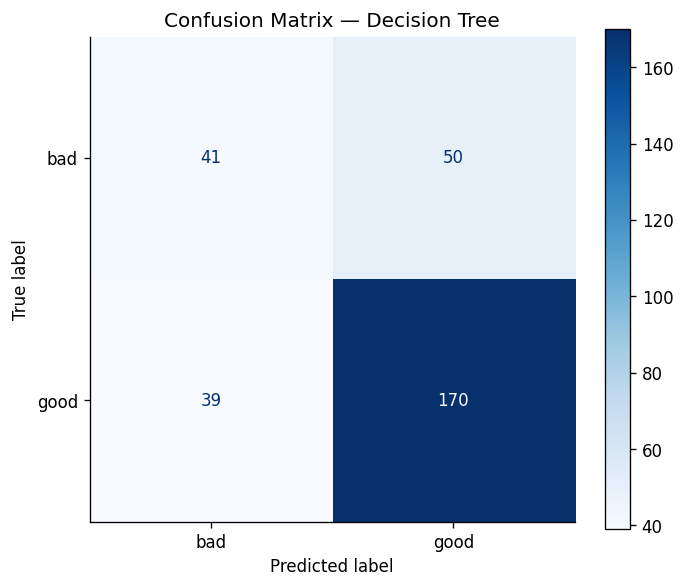

In [17]:
y_pred_dt = clf.predict(X_test_dt)
cm_dt = confusion_matrix(y_test_dt, y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=dt_class_names)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=True, cmap="Blues")
ax.set_title("Confusion Matrix — Decision Tree")
plt.tight_layout()
plt.show()

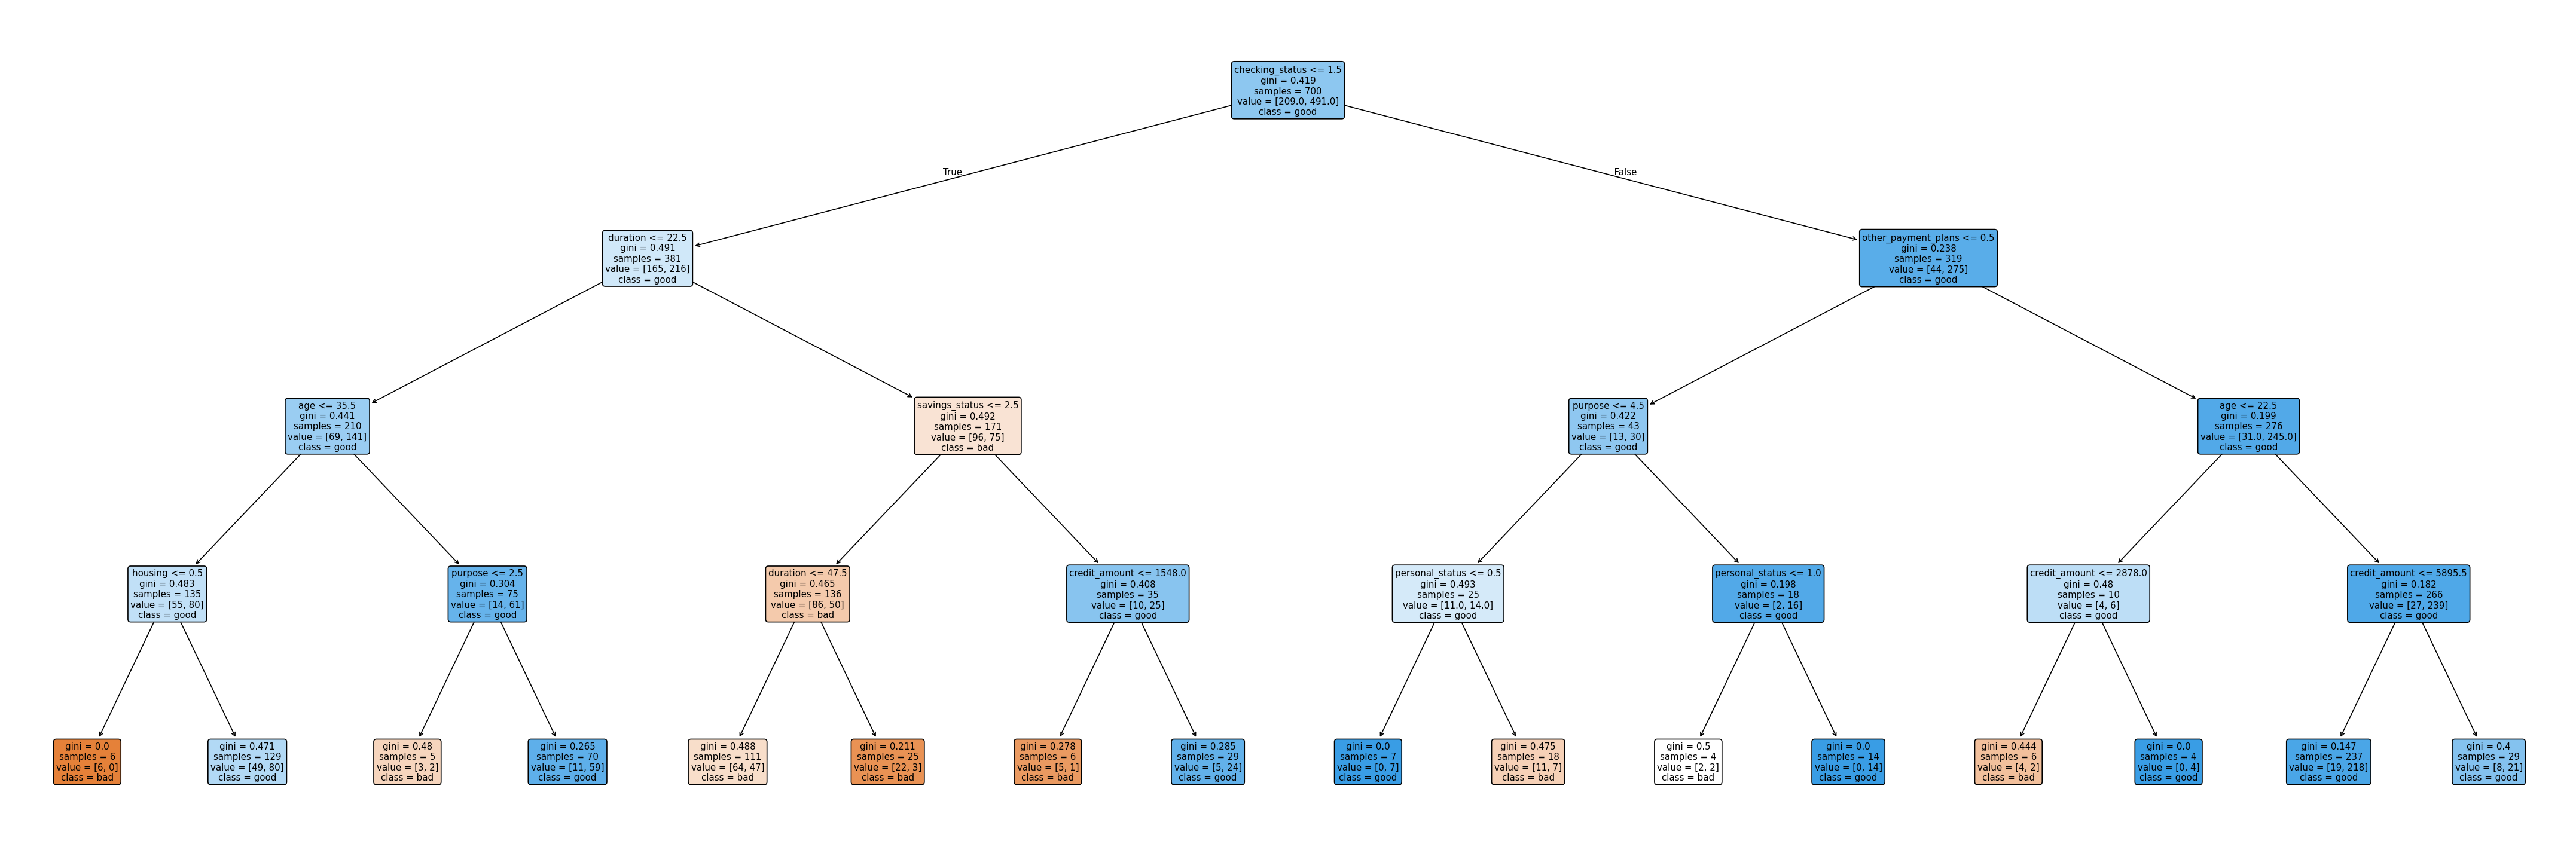

In [18]:
fig, ax = plt.subplots(figsize=(36, 12))
plot_tree(
    clf,
    feature_names=X_dt.columns.tolist(),
    class_names=dt_class_names,
    filled=True, rounded=True, fontsize=9, ax=ax
)
plt.tight_layout()
plt.show()

## Explainability (Decision Tree): LIME

Even though the Decision Tree is already interpretable natively (readable splits), LIME is applied here as well so that the local linear approximations can be directly compared to the tree's own decision path for the same instances.

In [19]:
dt_feature_names = list(X_dt.columns)
X_train_dt_np = X_train_dt.to_numpy()
X_test_dt_np  = X_test_dt.to_numpy()

dt_bad_label  = int(np.where(dt_class_names == "bad")[0][0])  if "bad"  in list(dt_class_names) else 0
dt_good_label = int(np.where(dt_class_names == "good")[0][0]) if "good" in list(dt_class_names) else 1

# Categorical column indices for LIME (same original categorical columns, minus class)
dt_cat_indices = [
    dt_feature_names.index(c)
    for c in df.select_dtypes(include="object").columns.tolist()
    if c != "class" and c in dt_feature_names
]

def dt_predict_fn(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x)
    if x.ndim == 1:
        x = x.reshape(1, -1)
    x_df = pd.DataFrame(x, columns=dt_feature_names)
    return clf.predict_proba(x_df)

lime_explainer_dt = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_dt_np,
    feature_names=dt_feature_names,
    class_names=list(dt_class_names),
    categorical_features=dt_cat_indices,
    mode="classification",
    random_state=RANDOM_STATE
)

print("DT LIME explainer created.")

# Case picker
dt_pred_labels = clf.predict(X_test_dt)
dt_bad_idxs  = np.where(dt_pred_labels == dt_bad_label)[0]
dt_good_idxs = np.where(dt_pred_labels == dt_good_label)[0]

dt_bad_i  = int(dt_bad_idxs[0])  if len(dt_bad_idxs)  else None
dt_good_i = int(dt_good_idxs[0]) if len(dt_good_idxs) else None

print("DT selected indices:")
print("  BAD predicted :", dt_bad_i)
print("  GOOD predicted:", dt_good_i)

DT LIME explainer created.
DT selected indices:
  BAD predicted : 2
  GOOD predicted: 0


### DT Local LIME Explanations — BAD and GOOD

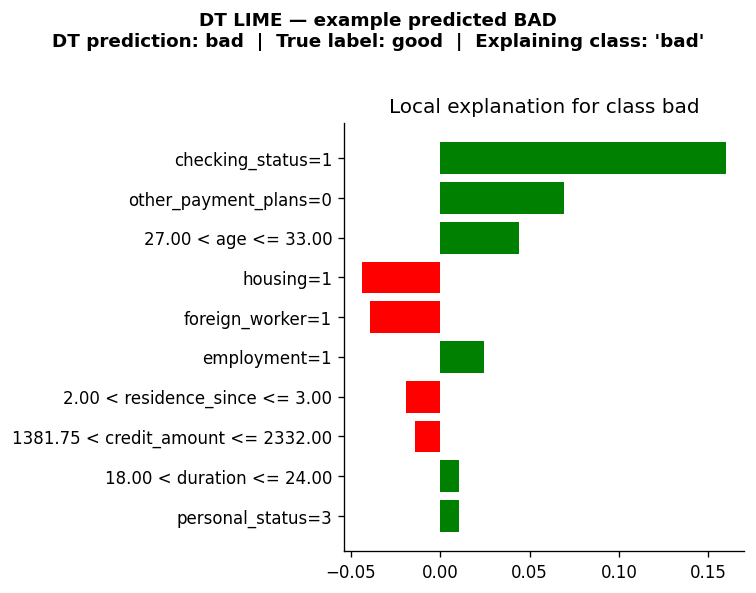


[DT LIME — example predicted BAD]  top-10 feature contributions toward 'bad':
  +  0.1598   checking_status=1
  +  0.0690   other_payment_plans=0
  +  0.0441   27.00 < age <= 33.00
  -  0.0438   housing=1
  -  0.0392   foreign_worker=1
  +  0.0244   employment=1
  -  0.0194   2.00 < residence_since <= 3.00
  -  0.0141   1381.75 < credit_amount <= 2332.00
  +  0.0105   18.00 < duration <= 24.00
  +  0.0104   personal_status=3

  Native DT decision path (4 splits):
    - checking_status <= 1.500  (val=1)
    - duration > 22.500  (val=24.0)
    - savings_status <= 2.500  (val=0)
    - duration <= 47.500  (val=24.0)



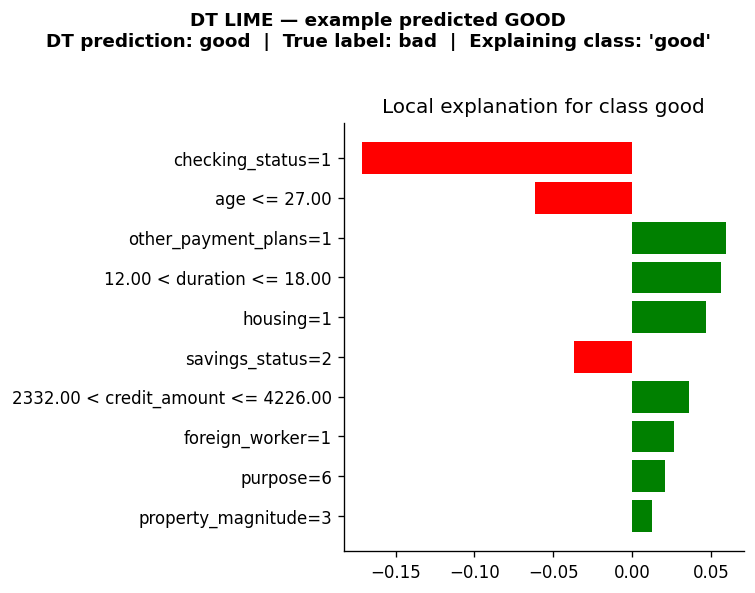


[DT LIME — example predicted GOOD]  top-10 feature contributions toward 'good':
  -  0.1714   checking_status=1
  -  0.0614   age <= 27.00
  +  0.0595   other_payment_plans=1
  +  0.0565   12.00 < duration <= 18.00
  +  0.0471   housing=1
  -  0.0365   savings_status=2
  +  0.0360   2332.00 < credit_amount <= 4226.00
  +  0.0264   foreign_worker=1
  +  0.0210   purpose=6
  +  0.0128   property_magnitude=3

  Native DT decision path (4 splits):
    - checking_status <= 1.500  (val=1)
    - duration <= 22.500  (val=18.0)
    - age <= 35.500  (val=24.0)
    - housing > 0.500  (val=1)



In [20]:
def show_lime_dt(idx: int, title: str, focus_label: int):
    """Run LIME for one DT instance and show bar-chart and decision path side-by-side."""
    if idx is None:
        print(f"[{title}] — no valid index, skipping.")
        return

    exp = lime_explainer_dt.explain_instance(
        X_test_dt_np[idx],
        dt_predict_fn,
        num_features=10,
        labels=(dt_bad_label, dt_good_label)
    )

    pred_name = dt_class_names[int(clf.predict(X_test_dt.iloc[[idx]])[0])]
    true_name = dt_class_names[int(y_test_dt[idx])]

    fig = exp.as_pyplot_figure(label=focus_label)
    fig.suptitle(
        f"{title}\nDT prediction: {pred_name}  |  True label: {true_name}  |  Explaining class: '{dt_class_names[focus_label]}'",
        fontsize=11, fontweight="bold", y=1.02
    )
    plt.tight_layout()
    plt.show()

    print(f"\n[{title}]  top-10 feature contributions toward '{dt_class_names[focus_label]}':")
    for feat, weight in exp.as_list(label=focus_label):
        direction = "+" if weight > 0 else "-"
        print(f"  {direction}  {abs(weight):.4f}   {feat}")
    print()

    # Also show the native DT decision path for comparison
    from sklearn.tree import _tree
    tree_ = clf.tree_
    node_id = 0
    path = []
    while tree_.feature[node_id] != _tree.TREE_UNDEFINED:
        f_idx  = tree_.feature[node_id]
        thresh = tree_.threshold[node_id]
        val    = X_test_dt.iloc[idx, f_idx]
        f_name = dt_feature_names[f_idx]
        if val <= thresh:
            path.append(f"{f_name} <= {thresh:.3f}  (val={val})")
            node_id = tree_.children_left[node_id]
        else:
            path.append(f"{f_name} > {thresh:.3f}  (val={val})")
            node_id = tree_.children_right[node_id]
    print(f"  Native DT decision path ({len(path)} splits):")
    for step in path:
        print(f"    - {step}")
    print()

show_lime_dt(dt_bad_i,  "DT LIME — example predicted BAD",  focus_label=dt_bad_label)
show_lime_dt(dt_good_i, "DT LIME — example predicted GOOD", focus_label=dt_good_label)

---
## Results Comparison: LIME vs SHAP vs Anchors

All three methods are applied to the same Random Forest and the same three test instances — one predicted BAD (index 4, true=good), one predicted GOOD (index 0, true=bad), and one misclassified (index 8, true=bad, predicted=good).

---

### Global Feature Importance

SHAP, LIME (mean |weight|), and the DT's built-in importance all agree on the dominant features:
`checking_status` > `duration` > `credit_amount` > `savings_status` > `age`.
The ranking is consistent across all three methods; magnitudes differ because each method measures importance differently. LIME places `purpose` at rank 3 (slightly above `credit_amount`), which differs mildly from SHAP and DT, but the top-2 are identical.

---

### Local Explanations per Instance

| Instance | SHAP top features | Anchor rule | LIME top features |
|----------|------------------|-------------|-------------------|
| BAD (idx 4, true=good) | credit_amount, age, checking_status, purpose | `age <= 27 AND personal_status AND credit_amount > 3965 AND purpose=new car AND checking_status AND credit_history` — precision 0.866, coverage 0.289 | `credit_amount > 3965` (+), `checking_status=0` (+), `purpose=4` (+), `age <= 27` (+); `duration <= 12` (−), `savings_status=4` (−) |
| GOOD (idx 0, true=bad) | checking_status, age | `age > 33 AND checking_status=no checking` — precision 0.967, coverage 0.476 | `checking_status=3` strongly dominant (+0.175); `credit_amount > 3965` pushes against (−0.08) |
| Misclassified (idx 8, true=bad) | checking_status, duration | `duration <= 24 AND checking_status=no checking` — precision 0.953, coverage 0.763 | `checking_status=3` dominant (+0.175), `duration <= 12` (+0.085), `purpose=6` (+), `savings_status=4` (+) |

---

### Method Comparison

| | LIME | SHAP | Anchors |
|---|---|---|---|
| Output | Signed feature weights | Signed attribution values | IF/THEN rule |
| Scope | Local + Global | Local + Global | Local |
| Model-agnostic | Yes | No (uses tree internals) | Yes |
| Precision guarantee | No | No | Yes |
| Speed | Moderate | Fast | Slow |

SHAP, LIME, and Anchors all agree on `checking_status` as the dominant feature, particularly for the GOOD and misclassified instances. On the BAD instance (idx 4), all three again converge on `credit_amount`, `checking_status`, `age`, and `purpose` — but LIME additionally surfaces `duration` and `savings_status` as features actively working *against* the bad prediction, a nuance that Anchors (rule-based) and SHAP (global) both miss at first glance. The misclassified instance is the most consistent across all methods: `checking_status` and short `duration` dominate in LIME, match the Anchor rule exactly, and align with the SHAP waterfall — making it the clearest case of a model confidently wrong in a locally explainable way.